<a href="https://colab.research.google.com/github/soleildayana/Modern-Astrophysics/blob/main/TransfLorentz_DiagramasMinkowski.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transformaciones de Lorentz — Entrega Taller 1 de Astrofísica Moderna

**Soleil Dayana Niño Murcia**
### Invariancia del intervalo, marcos especiales y diagramas de Minkowski

**Convenciones (unidades naturales, $c=1$, 1+1 dimensiones):**

Boost de Lorentz a lo largo de $x$:
$$t' = \gamma(t - v x), \qquad x' = \gamma(x - v t), \qquad \gamma(v) = \frac{1}{\sqrt{1-v^2}}$$

Intervalo espacio-temporal (firma $+,-$):
$$\Delta s^2 = (\Delta t)^2 - (\Delta x)^2$$

Clasificación causal:
- **Timelike** ($\Delta s^2 > 0$): existe un marco $S'$ donde $\Delta x' = 0$; el tiempo propio es $\Delta\tau = \sqrt{\Delta s^2}$.
- **Spacelike** ($\Delta s^2 < 0$): existe un marco $S'$ donde $\Delta t' = 0$; la distancia propia es $\Delta L = \sqrt{-\Delta s^2}$.
- **Lightlike** ($\Delta s^2 = 0$): conectados por una señal luminosa, ningún marco masivo los ve simultáneos ni coincidentes.

El intervalo es un invariante de Lorentz: $\Delta s'^2 = \Delta s^2$ para cualquier $|v|<1$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Definir funciones básicas:

In [2]:
def gamma(v):
  """Factor de Lorentz gamma(v) = 1/sqrt(1 - v^2).
  """
  return 1.0 / np.sqrt(1.0 - v**2)


def lorentz_boost(t, x, v):
  """Aplica un boost de Lorentz a lo largo de x a las coordenadas (t, x).

  Parámetros
  ----------
  t, x : float o array
      Coordenadas del evento en el marco S.
  v : float
      Velocidad del marco S' respecto a S (en unidades de c).

  Retorna
  -------
  (t_prima, x_prima) : tuple
      Coordenadas del evento medidas en el marco S'.
  """
  g = gamma(v)
  t_prima = g * (t - v * x)
  x_prima = g * (x - v * t)
  return t_prima, x_prima


def interval2(dt, dx):
  """Intervalo espacio-temporal al cuadrado: ds^2 = dt^2 - dx^2 (firma +,-)."""
  return dt**2 - dx**2

tol = 1e-12

def classify_interval(ds2, tol=tol):
  """Clasifica un intervalo ds^2 como 'timelike', 'spacelike' o 'lightlike'."""
  if ds2 > tol:
      return "timelike"
  elif ds2 < -tol:
      return "spacelike"
  else:
      return "lightlike"

## Paso 2 — Eventos de prueba

In [3]:
# Definimos pares de eventos procurando cubrir cada uno de los tipos de clasificación
pares_eventos = {
    "Par 1": {"A": (0.0, 0.0), "B": (5.0, 2.0), "tipo_esperado": "timelike"},
    "Par 2": {"A": (0.0, 0.0), "B": (2.0, 5.0), "tipo_esperado": "spacelike"},
    "Par 3": {"A": (0.0, 0.0), "B": (3.0, 3.0), "tipo_esperado": "lightlike"},
    "Par 4": {"A": (1.0, 1.0), "B": (2.0, 6.0), "tipo_esperado": "spacelike (libre)"},
    "Par 5": {"A": (0.0, 1.0), "B": (6.0, 3.0), "tipo_esperado": "timelike (libre)"},
}

# Para cada par, calculamos dt, ds y su clasificación

for nombre, par in pares_eventos.items():
    t1, x1 = par["A"]
    t2, x2 = par["B"]
    dt, dx = t2 - t1, x2 - x1
    ds2 = interval2(dt, dx)
    print(f"{nombre}: A={par['A']}, B={par['B']}  ->  dt={dt}, dx={dx}, "
          f"ds^2={ds2:.2f}  ({classify_interval(ds2)})")

Par 1: A=(0.0, 0.0), B=(5.0, 2.0)  ->  dt=5.0, dx=2.0, ds^2=21.00  (timelike)
Par 2: A=(0.0, 0.0), B=(2.0, 5.0)  ->  dt=2.0, dx=5.0, ds^2=-21.00  (spacelike)
Par 3: A=(0.0, 0.0), B=(3.0, 3.0)  ->  dt=3.0, dx=3.0, ds^2=0.00  (lightlike)
Par 4: A=(1.0, 1.0), B=(2.0, 6.0)  ->  dt=1.0, dx=5.0, ds^2=-24.00  (spacelike)
Par 5: A=(0.0, 1.0), B=(6.0, 3.0)  ->  dt=6.0, dx=2.0, ds^2=32.00  (timelike)


## Aplicado en **Ejercicio 1**: Verificación de invariancia aplicando boosts

Para cada par de eventos se calcula $\Delta s^2$ en $S$, se transforman $A$ y $B$ a marcos
$S'$ con $v \in \{0.1,\,0.5,\,0.9,\,-0.4\}$, se recomputa $\Delta s'^2$ y se verifica
$|\Delta s^2 - \Delta s'^2| < 10^{-12}$.

In [4]:
velocidades_prueba = [0.1, 0.5, 0.9]

filas = []
for nombre, par in pares_eventos.items():
  t1, x1 = par["A"]
  t2, x2 = par["B"]
  dt, dx = t2 - t1, x2 - x1
  ds2 = interval2(dt, dx)

  for v in velocidades_prueba:
    t1p, x1p = lorentz_boost(t1, x1, v)
    t2p, x2p = lorentz_boost(t2, x2, v)
    dtp, dxp = t2p - t1p, x2p - x1p
    ds2p = interval2(dtp, dxp)
    diff = abs(ds2 - ds2p)

    filas.append({
        "Par": nombre,
        "v": v,
        "Δs² (S)": ds2,
        "Δs'² (S')": ds2p,
        "|Δs²-Δs'²|": diff,
        "Invariante (<1e-12)": diff < tol,
        "Clasificación": classify_interval(ds2)
      })

tabla_ej1 = pd.DataFrame(filas)
tabla_ej1

,Par,v,Δs² (S),Δs'² (S'),|Δs²-Δs'²|,Invariante (<1e-12),Clasificación
0,Par 1,0.1,21.0,21.0,0.000000e+00,True,timelike
1,Par 1,0.5,21.0,21.0,7.105427e-15,True,timelike
2,Par 1,0.9,21.0,21.0,7.105427e-15,True,timelike
3,Par 2,0.1,-21.0,-21.0,0.000000e+00,True,spacelike
4,Par 2,0.5,-21.0,-21.0,7.105427e-15,True,spacelike
5,Par 2,0.9,-21.0,-21.0,7.105427e-15,True,spacelike
6,Par 3,0.1,0.0,0.0,0.000000e+00,True,lightlike
7,Par 3,0.5,0.0,0.0,0.000000e+00,True,lightlike
8,Par 3,0.9,0.0,0.0,0.000000e+00,True,lightlike
9,Par 4,0.1,-24.0,-24.0,0.000000e+00,True,spacelike


La invarianza se cumple en TODOS los casos ya que se comprueba que la diferencia $|\Delta s^2 - \Delta s'^2| < 10^{-12}$ es básicamente nula.

## Ejercicio 2: Marcos especiales y límites

**Spacelike ($\Delta s^2 < 0$):** existe $v_{sim}$ tal que $\Delta t' = 0$. De
$t' = \gamma(\Delta t - v\Delta x)$, la condición $\Delta t' = 0$ exige

$$v_{sim} = \frac{\Delta t}{\Delta x}$$

En ese marco la separación es la **distancia propia** $\Delta L = \sqrt{-\Delta s^2}$.

**Timelike ($\Delta s^2 > 0$):** existe $v_{co}$ tal que $\Delta x' = 0$. De
$x' = \gamma(\Delta x - v\Delta t)$, la condición $\Delta x' = 0$ exige

$$v_{co} = \frac{\Delta x}{\Delta t}$$

En ese marco el tiempo transcurrido es el **tiempo propio** $\Delta\tau = \sqrt{\Delta s^2}$.

Ambas velocidades se verifican también por **búsqueda numérica** sobre
`v = np.linspace(-0.99, 0.99, 1000)`.

In [5]:
def v_simultaneidad_analitico(dt, dx):
  """v tal que Delta t' = 0 (para separaciones spacelike)"""
  return dt / dx


def v_coincidencia_analitico(dt, dx):
  """v tal que Delta x' = 0 (para separaciones timelike)"""
  return dx / dt


def buscar_v_numerico(dt, dx, objetivo="dt_prima"):
    """Busqueda en v in (-0.99, 0.99) que minimiza |Delta t'| o |Delta x'|."""
    vs = np.linspace(-0.99, 0.99, 1000)
    g = gamma(vs)
    if objetivo == "dt_prima":
        # minimizar |Delta t'| = |gamma*(dt - v*dx)|
        valores = g * (dt - vs * dx)
    else:
        # minimizar |Delta x'| = |gamma*(dx - v*dt)|
        valores = g * (dx - vs * dt)
    idx = np.argmin(np.abs(valores))
    return vs[idx]

In [6]:
resultados_ej2 = {}

# Aplicamos a los eventos según la clasificación
for nombre, par in pares_eventos.items():
    t1, x1 = par["A"]
    t2, x2 = par["B"]
    dt, dx = t2 - t1, x2 - x1
    ds2 = interval2(dt, dx)
    tipo = classify_interval(ds2)

    entrada = {"dt": dt, "dx": dx, "ds2": ds2, "tipo": tipo}

    if tipo == "spacelike":
        v_sim_an = v_simultaneidad_analitico(dt, dx)
        v_sim_num = buscar_v_numerico(dt, dx, objetivo="dt_prima")
        dL = np.sqrt(-ds2)
        entrada.update({
            "v_especial_analitico": v_sim_an,
            "v_especial_numerico": v_sim_num,
            "marco_especial": "simultaneidad (Delta t' = 0)",
            "cantidad_propia": ("Distancia propia ΔL", dL),
        })

    elif tipo == "timelike":
        v_co_an = v_coincidencia_analitico(dt, dx)
        v_co_num = buscar_v_numerico(dt, dx, objetivo="dx_prima")
        dtau = np.sqrt(ds2)
        entrada.update({
            "v_especial_analitico": v_co_an,
            "v_especial_numerico": v_co_num,
            "marco_especial": "coincidencia espacial (Delta x' = 0)",
            "cantidad_propia": ("Tiempo propio Δτ", dtau),
        })

    else:
        entrada.update({
            "v_especial_analitico": None,
            "v_especial_numerico": None,
            "marco_especial": "no existe (lightlike)",
            "cantidad_propia": (None, None),
        })

    resultados_ej2[nombre] = entrada

filas2 = []
for nombre, r in resultados_ej2.items():
    if r["tipo"] == "lightlike":
        filas2.append({
            "Par": nombre, "Tipo": r["tipo"], "Marco especial": r["marco_especial"],
            "v (analítico)": np.nan, "v (numérico)": np.nan,
            "|diferencia|": np.nan, "Cantidad propia": np.nan, "Valor": np.nan,
        })
        continue
    v_an, v_num = r["v_especial_analitico"], r["v_especial_numerico"]
    label, valor = r["cantidad_propia"]
    filas2.append({
        "Par": nombre, "Tipo": r["tipo"], "Marco especial": r["marco_especial"],
        "v (analítico)": v_an, "v (numérico)": v_num,
        "|diferencia|": abs(v_an - v_num), "Cantidad propia": label, "Valor": valor,
    })

tabla_ej2 = pd.DataFrame(filas2)
tabla_ej2

,Par,Tipo,Marco especial,v (analítico),v (numérico),|diferencia|,Cantidad propia,Valor
0,Par 1,timelike,coincidencia espacial (Delta x' = 0),0.400000,0.399369,0.000631,Tiempo propio Δτ,4.582576
1,Par 2,spacelike,simultaneidad (Delta t' = 0),0.400000,0.399369,0.000631,Distancia propia ΔL,4.582576
2,Par 3,lightlike,no existe (lightlike),NaN,NaN,NaN,NaN,NaN
3,Par 4,spacelike,simultaneidad (Delta t' = 0),0.200000,0.199189,0.000811,Distancia propia ΔL,4.898979
4,Par 5,timelike,coincidencia espacial (Delta x' = 0),0.333333,0.333964,0.000631,Tiempo propio Δτ,5.656854


In [7]:
print("Comparación analítico vs. numérico:\n")
for nombre, r in resultados_ej2.items():
  if r["tipo"] == "lightlike":
      print(f"{nombre} (lightlike): no existe marco especial de simultaneidad ni coincidencia.")
      continue
  label, valor = r["cantidad_propia"]
  print(f"{nombre} ({r['tipo']}): {r['marco_especial']}")
  print(f"   v analítico = {r['v_especial_analitico']:.6f}   "
        f"v numérico = {r['v_especial_numerico']:.6f}   "
        f"|diff| = {abs(r['v_especial_analitico'] - r['v_especial_numerico']):.6f}")
  print(f"   {label} = {valor:.6f}\n")

Comparación analítico vs. numérico:

Par 1 (timelike): coincidencia espacial (Delta x' = 0)
   v analítico = 0.400000   v numérico = 0.399369   |diff| = 0.000631
   Tiempo propio Δτ = 4.582576

Par 2 (spacelike): simultaneidad (Delta t' = 0)
   v analítico = 0.400000   v numérico = 0.399369   |diff| = 0.000631
   Distancia propia ΔL = 4.582576

Par 3 (lightlike): no existe marco especial de simultaneidad ni coincidencia.
Par 4 (spacelike): simultaneidad (Delta t' = 0)
   v analítico = 0.200000   v numérico = 0.199189   |diff| = 0.000811
   Distancia propia ΔL = 4.898979

Par 5 (timelike): coincidencia espacial (Delta x' = 0)
   v analítico = 0.333333   v numérico = 0.333964   |diff| = 0.000631
   Tiempo propio Δτ = 5.656854



###  Diagramas de Minkowski

Para cada par se grafican los eventos $A$ y $B$, la línea de universo que los une, el cono
de luz ($x=\pm t$) y, cuando existe, los ejes transformados $ct'$ (recta $x=vt$) y $x'$
(recta $t=vx$) del marco especial hallado.

In [8]:
def graficar_minkowski(ax, nombre, par, resultado):
  t1, x1 = par["A"]
  t2, x2 = par["B"]
  tipo = resultado["tipo"]

  # rango de la gráfica según los eventos
  lim = max(abs(t1), abs(x1), abs(t2), abs(x2)) * 1.4 + 1
  tt = np.linspace(-lim, lim, 200)

  # cono de luz
  ax.plot(tt, tt, 'k--', lw=1, alpha=0.6, label='cono de luz (x=t)')
  ax.plot(tt, -tt, 'k--', lw=1, alpha=0.6)

  # eventos y línea de universo (convención: eje x = espacio, eje y = tiempo)
  ax.plot([x1, x2], [t1, t2], 'o-', color='tab:blue', ms=8, lw=2,
          label='línea de universo A→B')
  ax.annotate('A', (x1, t1), textcoords="offset points", xytext=(8, 4))
  ax.annotate('B', (x2, t2), textcoords="offset points", xytext=(8, 4))

  # ejes transformados del marco especial (si existe)
  if resultado["v_especial_analitico"] is not None:
      v = resultado["v_especial_analitico"]
      # eje ct': recta x = v*t  -> graficar t en tt, x = v*t
      ax.plot(v * tt, tt, color='tab:red', lw=1.5,
              label=f"eje ct' (x=v·t), v={v:.3f}")
      # eje x': recta t = v*x -> graficar x en tt, t = v*x
      ax.plot(tt, v * tt, color='tab:green', lw=1.5,
              label=f"eje x' (t=v·x), v={v:.3f}")
  else:
      # Caso lightlike: no existe boost que dé simultaneidad ni coincidencia
      # espacial, porque ambos eventos ya están sobre el cono de luz. Se deja
      # constancia explícita en el panel en vez de omitir la anotación.
      ax.text(0.5, 0.02,
                "No existe marco especial:\nseparación lightlike (Δs²=0)",
                transform=ax.transAxes, ha='center', va='bottom',
                fontsize=8, color='dimgray',
                bbox=dict(boxstyle='round', fc='white', ec='dimgray', alpha=0.8))

  ax.set_xlim(-lim, lim)
  ax.set_ylim(-lim, lim)
  ax.set_xlabel('x')
  ax.set_ylabel('t')
  ax.axhline(0, color='gray', lw=0.5)
  ax.axvline(0, color='gray', lw=0.5)
  ax.set_aspect('equal')
  ax.grid(True, alpha=0.3)
  ax.set_title(f"{nombre} — {tipo}\nΔs²={resultado['ds2']:.2f}")
  ax.legend(fontsize=7, loc='upper left')

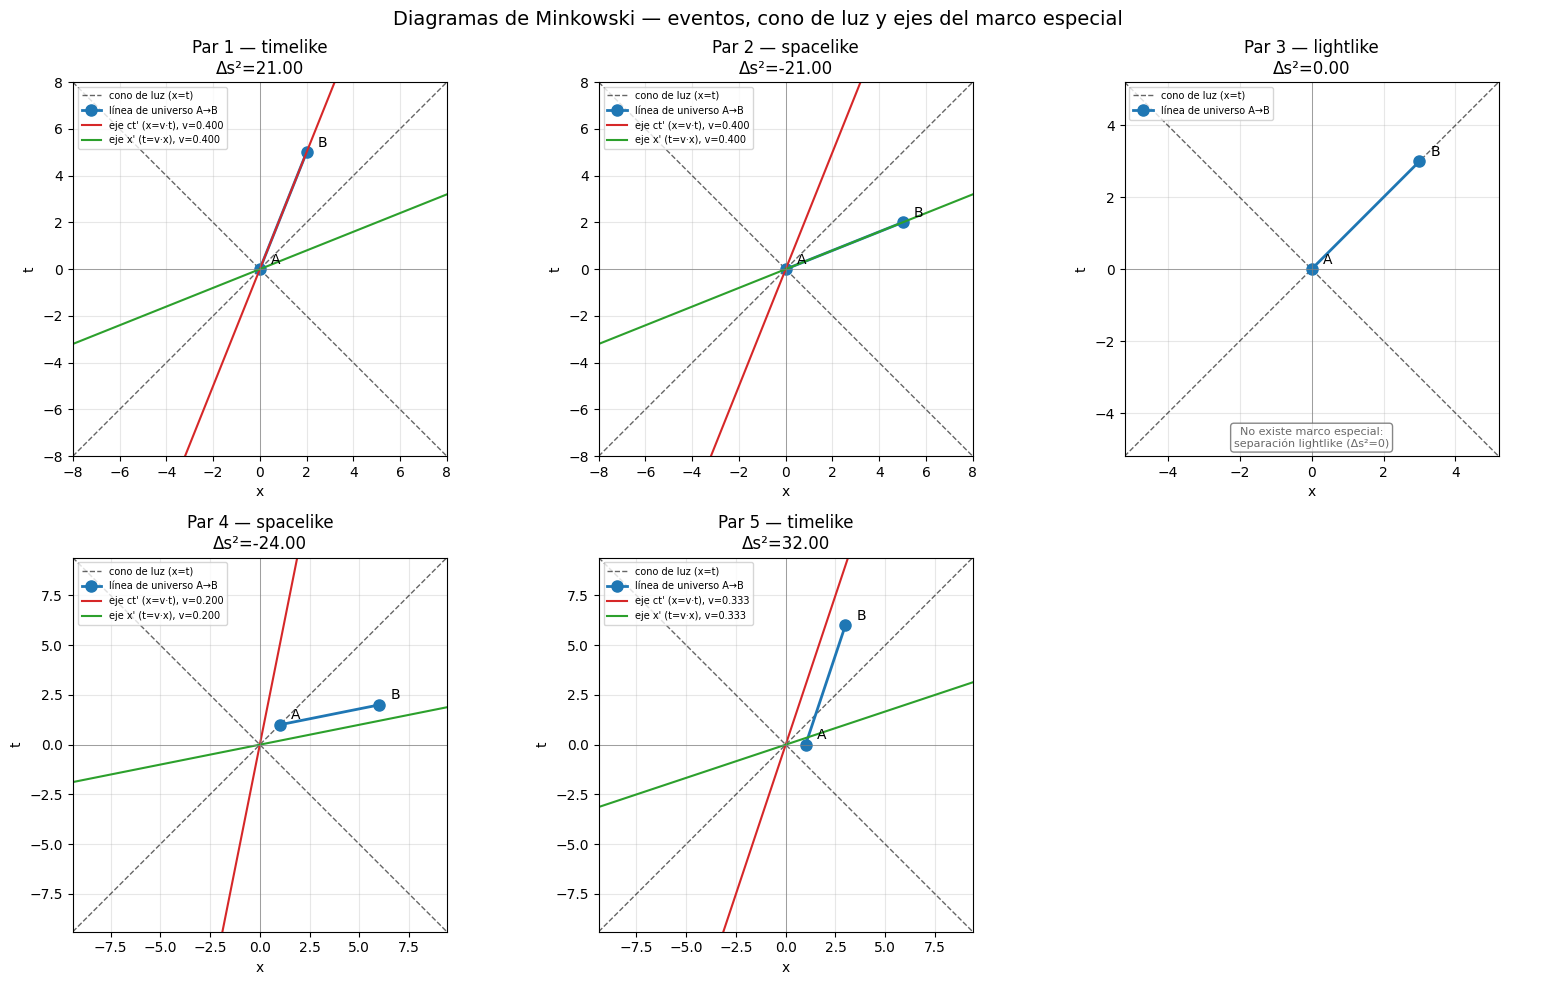

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, (nombre, par) in zip(axes, pares_eventos.items()):
  graficar_minkowski(ax, nombre, par, resultados_ej2[nombre])

axes[-1].axis('off')  # sobra un panel (5 pares en 2x3)

fig.suptitle("Diagramas de Minkowski — eventos, cono de luz y ejes del marco especial", fontsize=14)
fig.tight_layout()
plt.show()

## Conclusión

El intervalo espacio-temporal $\Delta s^2 = (\Delta t)^2 - (\Delta x)^2$ permanece
numéricamente invariante ($|\Delta s^2 - \Delta s'^2| < 10^{-12}$) bajo cualquier boost de Lorentz con $|v|<1$, tal como confirma la Tabla del Ejercicio 1 para los cinco pares de eventos y las cuatro velocidades de prueba. Esta invariancia es la que permite clasificar independiente del observador la separación entre dos eventos como timelike, spacelike o lightlike. Ningún boost puede convertir un intervalo timelike en spacelike ni viceversa, porque el signo de $\Delta s^2$ no cambia.